In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv(r"C:\Users\solan\Downloads\chattogram_weather_5years.csv")

In [6]:
df.head()

,Date,Temp_C,Humidity_%,Rainfall_mm,Wind_kmh,Condition
0,2019-01-01,19.2,64,2.9,12,Sunny
1,2019-01-02,19.6,74,8.3,16,Rainy
2,2019-01-03,19.0,79,3.1,13,Sunny
3,2019-01-04,20.6,68,8.3,20,Rainy
4,2019-01-05,19.5,66,4.7,22,Sunny


In [8]:
df.shape

(1826, 6)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         1826 non-null   object 
 1   Temp_C       1826 non-null   float64
 2   Humidity_%   1826 non-null   int64  
 3   Rainfall_mm  1826 non-null   float64
 4   Wind_kmh     1826 non-null   int64  
 5   Condition    1826 non-null   object 
dtypes: float64(2), int64(2), object(2)
memory usage: 85.7+ KB


In [11]:
df.isnull().sum()

Date           0
Temp_C         0
Humidity_%     0
Rainfall_mm    0
Wind_kmh       0
Condition      0
dtype: int64

In [14]:
df.describe()

,Temp_C,Humidity_%,Rainfall_mm,Wind_kmh
count,1826.000000,1826.000000,1826.000000,1826.000000
mean,25.778970,75.333516,8.735433,14.916758
std,3.209077,9.352515,11.125410,4.289353
min,19.000000,60.000000,0.000000,8.000000
25%,22.800000,68.000000,0.000000,11.000000
50%,26.700000,75.000000,4.500000,15.000000
75%,28.300000,83.000000,12.375000,19.000000
max,31.000000,92.000000,69.000000,22.000000


In [18]:
num = df.select_dtypes(include=np.number)
num

,Temp_C,Humidity_%,Rainfall_mm,Wind_kmh
0,19.2,64,2.9,12
1,19.6,74,8.3,16
2,19.0,79,3.1,13
3,20.6,68,8.3,20
4,19.5,66,4.7,22
...,...,...,...,...
1821,21.6,61,0.5,9
1822,22.0,63,0.9,18
1823,21.8,72,3.0,21
1824,21.1,68,0.0,17


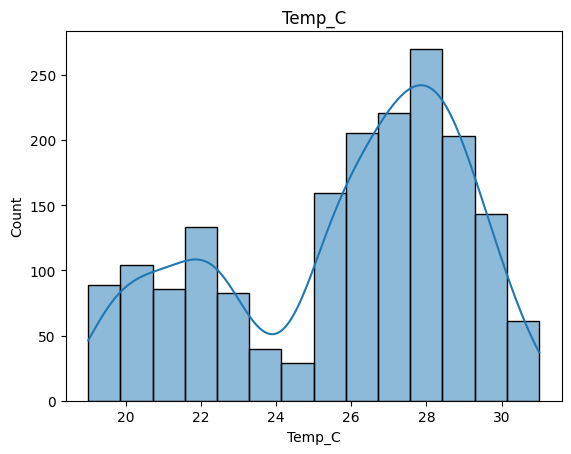

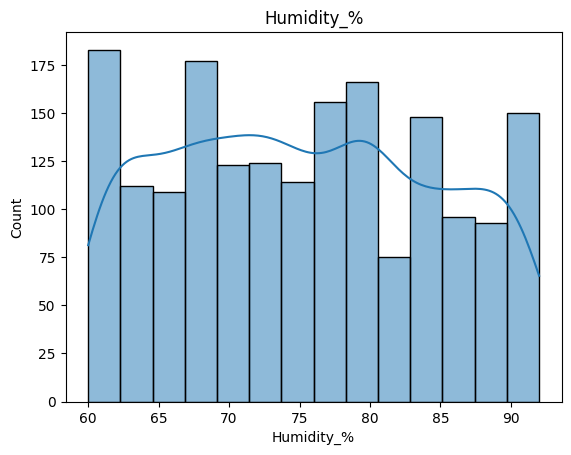

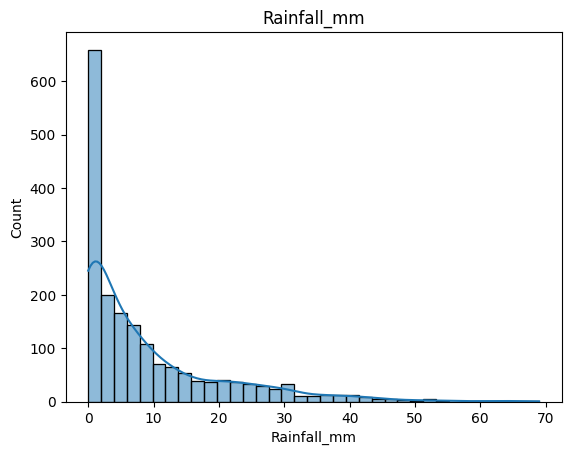

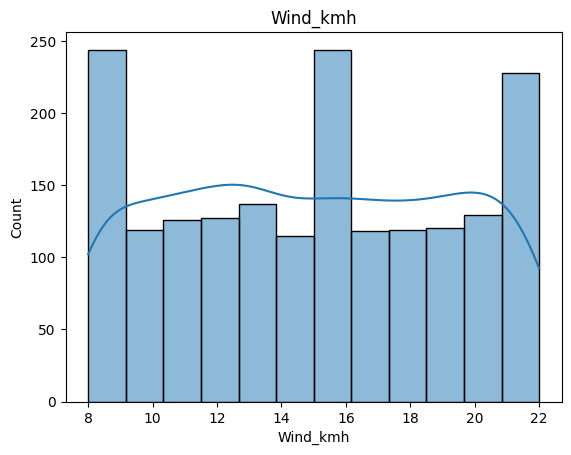

In [19]:
for i in num.columns:
    sns.histplot(num[i], kde=True)
    plt.title(i)
    plt.show()

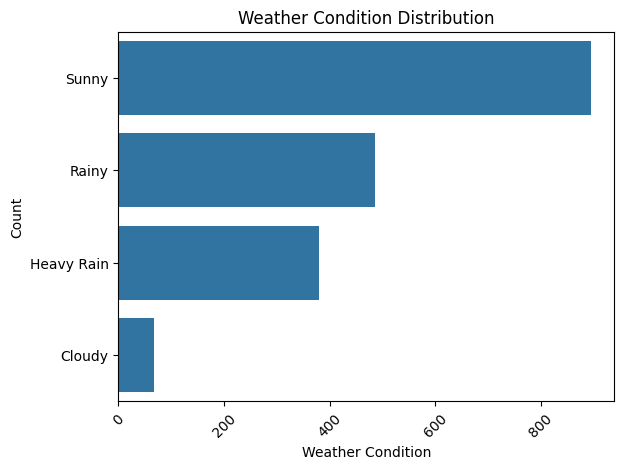

In [21]:
sns.countplot(df["Condition"])
plt.title("Weather Condition Distribution")
plt.xlabel("Weather Condition")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

<Axes: >

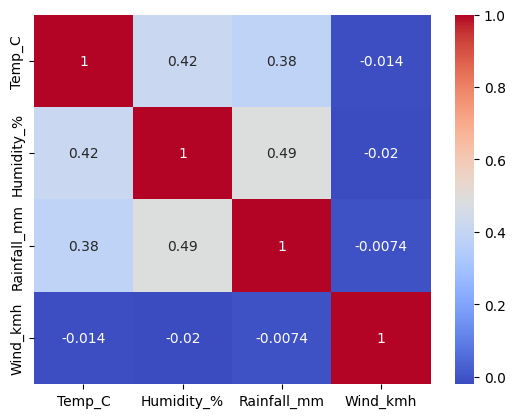

In [22]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

In [24]:
df.drop(["Date"], axis=1, inplace=True)

In [26]:
df.head()

,Temp_C,Humidity_%,Rainfall_mm,Wind_kmh,Condition
0,19.2,64,2.9,12,Sunny
1,19.6,74,8.3,16,Rainy
2,19.0,79,3.1,13,Sunny
3,20.6,68,8.3,20,Rainy
4,19.5,66,4.7,22,Sunny


In [31]:
from sklearn.preprocessing import LabelEncoder

In [33]:
le = LabelEncoder()
df["Condition"] = le.fit_transform(df["Condition"])

In [34]:
df.head()

,Temp_C,Humidity_%,Rainfall_mm,Wind_kmh,Condition
0,19.2,64,2.9,12,3
1,19.6,74,8.3,16,2
2,19.0,79,3.1,13,3
3,20.6,68,8.3,20,2
4,19.5,66,4.7,22,3


In [35]:
X = df.drop("Condition", axis=1)
y = df["Condition"]

In [38]:
from scipy.stats import pearsonr

In [40]:
Selected_Features = ["Temp_C", "Humidity_%", "Rainfall_mm", "Wind_kmh", "Condition"]
correlations = {
    feature: pearsonr(df[feature], df["Condition"])[0] 
    for feature in Selected_Features[:-1]
}
correlaion_df = pd.DataFrame(list(correlations.items()), columns=["Feature", "Correlation_with_Condition"])
correlaion_df.sort_values(by="Correlation_with_Condition", ascending=False)

,Feature,Correlation_with_Condition
3,Wind_kmh,0.025303
0,Temp_C,-0.436246
1,Humidity_%,-0.615668
2,Rainfall_mm,-0.694563


In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [41]:
from sklearn.preprocessing import StandardScaler

In [43]:
sclaer = StandardScaler()

X_train_scaled = sclaer.fit_transform(X_train)
X_test_scaled = sclaer.transform(X_test)

In [44]:
from sklearn.linear_model import LogisticRegression

In [46]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [54]:
print(y_test)

998     1
1518    3
298     3
415     3
1120    2
       ..
637     1
1611    3
607     1
994     3
1228    3
Name: Condition, Length: 366, dtype: int64


In [55]:
print(model.predict(X_test_scaled))

[1 3 3 3 2 3 3 2 3 3 3 1 2 2 2 3 2 1 3 3 2 1 2 2 1 1 3 2 3 3 3 3 3 3 2 3 1
 1 2 3 3 1 2 1 0 1 3 3 3 1 1 2 2 3 1 3 3 2 3 3 2 2 1 1 3 2 2 2 3 0 3 3 2 2
 1 3 3 2 3 2 2 2 2 2 3 2 1 3 2 0 2 3 3 3 1 3 2 1 3 2 0 3 3 3 1 3 3 2 0 3 2
 3 2 1 1 1 3 3 3 3 2 1 3 3 1 3 1 2 0 3 3 3 3 1 2 1 3 3 0 2 2 3 2 3 3 1 3 1
 3 3 3 1 1 3 2 3 2 3 1 2 2 3 3 1 3 2 3 1 3 1 1 1 3 3 3 1 2 2 3 3 3 3 3 1 3
 2 1 3 3 1 2 3 2 3 2 3 2 3 3 3 3 3 1 2 3 3 3 3 2 2 2 2 3 2 2 3 3 3 2 3 2 1
 3 1 1 2 3 2 3 3 3 3 3 2 2 3 2 3 3 1 3 1 1 1 2 3 3 2 2 3 3 3 1 1 1 3 2 2 1
 3 3 3 2 2 3 1 1 3 2 3 1 1 3 3 1 3 2 2 3 3 3 2 2 2 3 3 3 1 3 3 2 2 1 1 3 1
 1 1 3 2 2 1 3 1 3 3 3 3 3 3 3 3 3 3 3 1 2 3 3 2 2 3 3 0 3 2 3 3 2 1 2 1 2
 1 2 1 1 1 3 3 1 2 1 3 3 2 3 3 2 3 3 3 2 1 3 1 1 2 2 2 3 1 3 1 3 3]


In [ ]:
condition_names = {0: "Cloudy",1: "Rainy",2: "Sunny",3: "Snowy"}

comparison_df = pd.DataFrame({
    "Actual_Condition": y_test.map(condition_names).values,
    "Predicted_Condition": pd.Series(
        model.predict(X_test_scaled)
    ).map(condition_names)
})

comparison_df.head(10)

,Actual_Condition,Predicted_Condition
0,Rainy,Rainy
1,Snowy,Snowy
2,Snowy,Snowy
3,Snowy,Snowy
4,Sunny,Sunny
5,Snowy,Snowy
6,Snowy,Snowy
7,Sunny,Sunny
8,Snowy,Snowy
9,Snowy,Snowy


In [47]:
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score

In [49]:
accuracy = accuracy_score(y_test, model.predict(X_test_scaled))
accuracy

0.9644808743169399

In [52]:
matrix = confusion_matrix(y_test, model.predict(X_test_scaled))
matrix

array([[  7,   0,   0,   2],
       [  0,  82,   2,   0],
       [  1,   0,  94,   3],
       [  0,   0,   5, 170]])

In [53]:
print(classification_report(y_test, model.predict(X_test_scaled)))

              precision    recall  f1-score   support

           0       0.88      0.78      0.82         9
           1       1.00      0.98      0.99        84
           2       0.93      0.96      0.94        98
           3       0.97      0.97      0.97       175

    accuracy                           0.96       366
   macro avg       0.94      0.92      0.93       366
weighted avg       0.96      0.96      0.96       366

